# Cleaned household clustering pipeline

This notebook combines the feature-building notebook and the refined two-stage clustering notebook into one safer end-to-end workflow.

## What it does
1. Load raw wide time-series data
2. Remove all-zero series
3. Build a clean series matrix
4. Extract interpretable time-series features
5. Optionally add catch22 features
6. Clean and stabilize the feature matrix
7. Split households into sparsity buckets using `zero_fraction`
8. Compare KMeans and GMM within each bucket across multiple `k`
9. Pick the best model per bucket using silhouette score
10. Save feature and cluster outputs


In [ ]:
#!pip install tslearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 17.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 23.3 MB/s eta 0:00:0000:0100:01


In [21]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from scipy.stats import linregress
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42


from tslearn.clustering import KShape
from tslearn.utils import to_time_series_dataset

## 1. Load raw sample data

In [22]:
file_2023 = Path("../data/raw/sample_23.csv")
data_2023 = pd.read_csv(file_2023)

display(data_2023.head())
print("Wide shape:", data_2023.shape)


,ID,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,...,2023-12-22,2023-12-23,2023-12-24,2023-12-25,2023-12-26,2023-12-27,2023-12-28,2023-12-29,2023-12-30,2023-12-31
0,22,13.482,9.473,10.146,10.978,14.149,11.536,7.767,10.081,9.189,...,8.4100,11.847,7.501,12.0760,12.5340,9.3860,9.5890,7.2150,8.623,12.769
1,42,46.427,49.369,40.441,38.126,40.902,28.853,23.482,42.429,43.268,...,36.6710,46.418,33.754,31.4390,25.3150,25.1880,38.3730,28.3060,32.604,51.493
2,56,9.088,9.300,8.860,13.168,8.341,8.592,14.704,13.383,8.189,...,11.9470,12.490,14.201,16.8190,10.8730,3.4240,0.1420,4.9070,10.655,4.467
3,58,10.040,7.633,11.596,8.036,10.404,6.576,8.617,15.368,8.773,...,14.1510,20.087,13.762,14.6370,21.0030,25.3060,5.2450,13.2220,13.909,16.507
4,64,2.969,2.427,2.018,2.742,2.118,2.879,1.961,2.161,2.256,...,2.5045,2.774,2.018,2.1118,2.1118,2.1118,2.1118,2.1118,2.367,2.729


Wide shape: (17547, 366)


## 2. Reshape to ID / Date / Value and remove all-zero series

In [23]:
date_columns = [col for col in data_2023.columns if col != "ID"]

long_df = data_2023.melt(
    id_vars="ID",
    value_vars=date_columns,
    var_name="Date",
    value_name="Value",
)

try:
    long_df["Date"] = pd.to_datetime(long_df["Date"])
    print("Date column parsed successfully.")
except Exception:
    print("Could not parse Date column automatically. Keeping as string.")

display(long_df.head())
print("Long shape:", long_df.shape)

id_all_zero = long_df.groupby("ID")["Value"].apply(lambda x: (x == 0).all())
print("Number of all-zero IDs:", int(id_all_zero.sum()))

valid_ids = id_all_zero.index[~id_all_zero]
filtered_long_df = long_df[long_df["ID"].isin(valid_ids)].reset_index(drop=True)

print("Filtered long shape:", filtered_long_df.shape)
display(filtered_long_df.head())


Date column parsed successfully.


,ID,Date,Value
0,22,2023-01-01,13.482
1,42,2023-01-01,46.427
2,56,2023-01-01,9.088
3,58,2023-01-01,10.040
4,64,2023-01-01,2.969


Long shape: (6404655, 3)
Number of all-zero IDs: 154
Filtered long shape: (6348445, 3)


,ID,Date,Value
0,22,2023-01-01,13.482
1,42,2023-01-01,46.427
2,56,2023-01-01,9.088
3,58,2023-01-01,10.040
4,64,2023-01-01,2.969


## 3. Pivot back to a clean time-series matrix

In [24]:
series_matrix = filtered_long_df.pivot(index="ID", columns="Date", values="Value")

try:
    series_matrix = series_matrix.sort_index(axis=1)
except Exception:
    pass

display(series_matrix.head())
print("Series matrix shape:", series_matrix.shape)
print("Missing values total:", int(series_matrix.isna().sum().sum()))

# Fill any missing values conservatively with 0 after pivot.
series_matrix = series_matrix.fillna(0.0)


Date,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10,...,2023-12-22,2023-12-23,2023-12-24,2023-12-25,2023-12-26,2023-12-27,2023-12-28,2023-12-29,2023-12-30,2023-12-31
ID,,,,,,,,,,,,,,,,,,,,,
22,13.482,9.473,10.146,10.978,14.149,11.536,7.767,10.081,9.189,14.919,...,8.4100,11.847,7.501,12.0760,12.5340,9.3860,9.5890,7.2150,8.623,12.769
42,46.427,49.369,40.441,38.126,40.902,28.853,23.482,42.429,43.268,36.268,...,36.6710,46.418,33.754,31.4390,25.3150,25.1880,38.3730,28.3060,32.604,51.493
56,9.088,9.300,8.860,13.168,8.341,8.592,14.704,13.383,8.189,8.156,...,11.9470,12.490,14.201,16.8190,10.8730,3.4240,0.1420,4.9070,10.655,4.467
58,10.040,7.633,11.596,8.036,10.404,6.576,8.617,15.368,8.773,6.134,...,14.1510,20.087,13.762,14.6370,21.0030,25.3060,5.2450,13.2220,13.909,16.507
64,2.969,2.427,2.018,2.742,2.118,2.879,1.961,2.161,2.256,3.755,...,2.5045,2.774,2.018,2.1118,2.1118,2.1118,2.1118,2.1118,2.367,2.729


Series matrix shape: (17393, 365)
Missing values total: 0


## 4. Feature helper functions

In [25]:
def safe_mean(x):
    return float(np.mean(x)) if len(x) > 0 else 0.0


def safe_std(x):
    return float(np.std(x, ddof=0)) if len(x) > 0 else 0.0


def coefficient_of_variation(x):
    m = np.mean(x)
    s = np.std(x, ddof=0)
    return float(s / m) if abs(m) > 1e-8 else 0.0


def autocorr_lag(x, lag):
    x = np.asarray(x, dtype=float)
    if len(x) <= lag:
        return 0.0
    x1 = x[:-lag]
    x2 = x[lag:]
    if np.std(x1) < 1e-8 or np.std(x2) < 1e-8:
        return 0.0
    return float(np.corrcoef(x1, x2)[0, 1])


def trend_slope(x):
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x))
    if np.std(x) < 1e-8:
        return 0.0
    return float(linregress(t, x).slope)


def zero_runs(x):
    runs = []
    run_len = 0
    for val in x:
        if val == 0:
            run_len += 1
        else:
            if run_len > 0:
                runs.append(run_len)
                run_len = 0
    if run_len > 0:
        runs.append(run_len)
    return runs


def nonzero_stats(x):
    nz = x[x != 0]
    if len(nz) == 0:
        return 0.0, 0.0, 0.0
    return float(np.mean(nz)), float(np.std(nz, ddof=0)), float(np.median(nz))


def rolling_features(x, window=7):
    s = pd.Series(x)
    roll_mean = s.rolling(window=window, min_periods=1).mean()
    roll_std = s.rolling(window=window, min_periods=1).std().fillna(0.0)
    return float(roll_mean.std()), float(roll_std.mean())


def burstiness(x):
    x = np.asarray(x, dtype=float)
    m = np.mean(x)
    s = np.std(x, ddof=0)
    if s + m < 1e-8:
        return 0.0
    return float((s - m) / (s + m))


def peak_features(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 3:
        return 0.0, 0.0
    peaks = []
    for i in range(1, len(x) - 1):
        if x[i] > x[i - 1] and x[i] > x[i + 1]:
            peaks.append(i)
    n_peaks = len(peaks)
    if n_peaks < 2:
        return float(n_peaks), 0.0
    avg_peak_spacing = float(np.mean(np.diff(peaks)))
    return float(n_peaks), avg_peak_spacing


def weekday_profile(x, dates):
    try:
        weekdays = pd.to_datetime(dates).weekday
    except Exception:
        return [0.0] * 7

    x = np.asarray(x, dtype=float)
    overall_mean = np.mean(x)
    if abs(overall_mean) < 1e-8:
        overall_mean = 1.0

    feats = []
    for d in range(7):
        vals = x[weekdays == d]
        feats.append(float(np.mean(vals) / overall_mean) if len(vals) > 0 else 0.0)
    return feats


def seasonal_peak_distribution(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return 0.0, 0.0
    threshold = np.quantile(x, 0.9)
    top_idx = np.where(x >= threshold)[0]
    if len(top_idx) == 0:
        return 0.0, 0.0
    first_half = np.mean(top_idx < len(x) / 2)
    second_half = np.mean(top_idx >= len(x) / 2)
    return float(first_half), float(second_half)


## 5. Extract custom features

In [26]:
def extract_features_from_series_matrix(series_matrix):
    feature_rows = []
    dates = np.array(series_matrix.columns)

    for idx, row in series_matrix.iterrows():
        x = row.to_numpy(dtype=float)

        mean_val = safe_mean(x)
        median_val = float(np.median(x))
        std_val = safe_std(x)
        cv_val = coefficient_of_variation(x)

        p10 = float(np.quantile(x, 0.10))
        p90 = float(np.quantile(x, 0.90))
        p90_p10_ratio = float(p90 / (p10 + 1e-8)) if abs(p10) > 1e-8 else 0.0

        max_val = float(np.max(x))
        max_median_ratio = float(max_val / (median_val + 1e-8)) if abs(median_val) > 1e-8 else 0.0

        above_p90_fraction = float(np.mean(x > p90)) if len(x) > 0 else 0.0

        slope = trend_slope(x)
        acf1 = autocorr_lag(x, 1)
        acf7 = autocorr_lag(x, 7)
        acf14 = autocorr_lag(x, 14)

        zero_fraction = float(np.mean(x == 0))
        nonzero_fraction = float(np.mean(x != 0))

        zruns = zero_runs(x)
        num_zero_runs = float(len(zruns))
        avg_zero_run_length = float(np.mean(zruns)) if len(zruns) > 0 else 0.0
        max_zero_run_length = float(np.max(zruns)) if len(zruns) > 0 else 0.0

        nonzero_mean, nonzero_std, nonzero_median = nonzero_stats(x)

        rolling7_mean_std, rolling7_std_mean = rolling_features(x, window=7)

        weekday_feats = weekday_profile(x, dates)
        weekday_weekend_gap = float(
            np.mean(weekday_feats[:5]) - np.mean(weekday_feats[5:])
        )

        burst = burstiness(x)
        n_peaks, avg_peak_spacing = peak_features(x)

        top10_first_half, top10_second_half = seasonal_peak_distribution(x)

        feature_rows.append({
            "ID": idx,
            "mean": mean_val,
            "median": median_val,
            "std": std_val,
            "cv": cv_val,
            "p90_p10_ratio": p90_p10_ratio,
            "max_median_ratio": max_median_ratio,
            "above_p90_fraction": above_p90_fraction,
            "trend_slope": slope,
            "acf1": acf1,
            "acf7": acf7,
            "acf14": acf14,
            "zero_fraction": zero_fraction,
            "nonzero_fraction": nonzero_fraction,
            "num_zero_runs": num_zero_runs,
            "avg_zero_run_length": avg_zero_run_length,
            "max_zero_run_length": max_zero_run_length,
            "nonzero_mean": nonzero_mean,
            "nonzero_std": nonzero_std,
            "nonzero_median": nonzero_median,
            "rolling7_mean_std": rolling7_mean_std,
            "rolling7_std_mean": rolling7_std_mean,
            "weekday_0_norm": weekday_feats[0],
            "weekday_1_norm": weekday_feats[1],
            "weekday_2_norm": weekday_feats[2],
            "weekday_3_norm": weekday_feats[3],
            "weekday_4_norm": weekday_feats[4],
            "weekday_5_norm": weekday_feats[5],
            "weekday_6_norm": weekday_feats[6],
            "weekday_weekend_gap": weekday_weekend_gap,
            "burstiness": burst,
            "num_peaks": n_peaks,
            "avg_peak_spacing": avg_peak_spacing,
            "top10_first_half": top10_first_half,
            "top10_second_half": top10_second_half,
        })

    return pd.DataFrame(feature_rows)


feature_df = extract_features_from_series_matrix(series_matrix)

display(feature_df.head())
print("Feature table shape:", feature_df.shape)

#output_file = Path("../data/processed/feature_based_clusters_2023_refined.csv")
#feature_df.to_csv(output_file, index=False)

,ID,mean,median,std,cv,p90_p10_ratio,max_median_ratio,above_p90_fraction,trend_slope,acf1,...,weekday_3_norm,weekday_4_norm,weekday_5_norm,weekday_6_norm,weekday_weekend_gap,burstiness,num_peaks,avg_peak_spacing,top10_first_half,top10_second_half
0,22,11.857921,11.432,3.973155,0.335063,2.367516,2.269419,0.10137,-0.009505,0.589803,...,1.040690,0.914279,0.957808,1.058417,-0.011582,-0.498056,123.0,2.926230,0.945946,0.054054
1,42,14.054819,3.610,18.955428,1.348678,478.927874,22.506371,0.10137,-0.022695,0.907323,...,0.904248,1.034863,1.113167,1.133149,-0.172934,0.148457,106.0,3.428571,0.648649,0.351351
2,56,5.609575,5.739,5.210435,0.928847,94.763497,4.092699,0.10137,-0.016571,0.783508,...,0.922266,0.878647,1.165745,1.098358,-0.185251,-0.036889,113.0,3.232143,0.702703,0.297297
3,58,9.320200,8.057,5.291708,0.567768,3.521268,4.936453,0.10137,0.016987,0.693289,...,0.952755,0.963350,1.069521,1.173497,-0.170780,-0.275699,113.0,3.196429,0.054054,0.945946
4,64,2.438655,2.422,0.514874,0.211130,1.616140,1.816680,0.09863,-0.000220,0.110696,...,0.999158,0.999269,1.014793,0.960737,0.017280,-0.651350,118.0,3.017094,0.631579,0.368421


Feature table shape: (17393, 35)


## 6. Optionally add catch22 features

In [27]:
USE_CATCH22 = False

if USE_CATCH22:
    try:
        import pycatch22

        catch22_rows = []
        for idx, row in series_matrix.iterrows():
            x = row.to_numpy(dtype=float)
            feats = pycatch22.catch22_all(x)
            row_dict = {"ID": idx}
            for name, value in zip(feats["names"], feats["values"]):
                row_dict[f"catch22_{name}"] = value
            catch22_rows.append(row_dict)

        catch22_df = pd.DataFrame(catch22_rows)
        feature_df = feature_df.merge(catch22_df, on="ID", how="left")
        print("catch22 features added.")
    except ImportError:
        print("pycatch22 is not installed. Skipping catch22 features.")

print("Feature table shape after optional catch22:", feature_df.shape)


Feature table shape after optional catch22: (17393, 35)


## 7. Clean and stabilize the feature matrix

In [28]:
def winsorize_series(s, lower_q=0.01, upper_q=0.99):
    lower = s.quantile(lower_q)
    upper = s.quantile(upper_q)
    return s.clip(lower=lower, upper=upper)


def is_heavy_tailed(s, ratio_threshold=10, skew_threshold=2):
    s = s.dropna()
    if len(s) == 0:
        return False
    q50 = s.quantile(0.50)
    q99 = s.quantile(0.99)
    ratio = (q99 + 1e-12) / (abs(q50) + 1e-12)
    skew = s.skew() if len(s) > 2 else 0
    return (ratio >= ratio_threshold) or (abs(skew) >= skew_threshold)


feature_df = feature_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

exclude_cols = [
    "ID",
    "Cluster",
    "SparsityGroup",
    "SparsityBucket",
    "RefinedClusterLocal",
    "RefinedCluster",
]
feature_cols = [c for c in feature_df.columns if c not in exclude_cols]

feature_df_clean = feature_df.copy()

heavy_tail_cols = []
for col in feature_cols:
    if pd.api.types.is_numeric_dtype(feature_df_clean[col]) and is_heavy_tailed(feature_df_clean[col]):
        heavy_tail_cols.append(col)

print("Heavy-tailed columns detected:", len(heavy_tail_cols))
print(heavy_tail_cols[:20])

for col in heavy_tail_cols:
    feature_df_clean[col] = winsorize_series(feature_df_clean[col], 0.01, 0.99)
    if (feature_df_clean[col] >= 0).all():
        feature_df_clean[col] = np.log1p(feature_df_clean[col])

display(feature_df_clean.head())


Heavy-tailed columns detected: 27
['mean', 'median', 'std', 'cv', 'p90_p10_ratio', 'max_median_ratio', 'above_p90_fraction', 'trend_slope', 'zero_fraction', 'nonzero_fraction', 'num_zero_runs', 'avg_zero_run_length', 'max_zero_run_length', 'nonzero_mean', 'nonzero_std', 'nonzero_median', 'rolling7_mean_std', 'rolling7_std_mean', 'weekday_0_norm', 'weekday_1_norm']


,ID,mean,median,std,cv,p90_p10_ratio,max_median_ratio,above_p90_fraction,trend_slope,acf1,...,weekday_3_norm,weekday_4_norm,weekday_5_norm,weekday_6_norm,weekday_weekend_gap,burstiness,num_peaks,avg_peak_spacing,top10_first_half,top10_second_half
0,22,2.553960,2.520274,1.604054,0.288979,1.214175,1.184612,0.096555,-0.009505,0.589803,...,0.713288,0.649341,0.671826,1.058417,-0.011582,-0.498056,4.820282,1.367680,0.945946,0.054054
1,42,2.711698,1.528228,2.993501,0.853853,5.183883,3.157271,0.096555,-0.022695,0.907323,...,0.644087,0.710428,0.748188,1.133149,-0.172934,0.148457,4.672829,1.488077,0.648649,0.351351
2,56,1.888519,1.907912,1.826231,0.656922,4.561882,1.627808,0.096555,-0.016571,0.783508,...,0.653505,0.630552,0.772765,1.098358,-0.185251,-0.036889,4.736198,1.442708,0.702703,0.297297
3,58,2.334103,2.203538,1.839233,0.449653,1.508793,1.781112,0.096555,0.016987,0.693289,...,0.669241,0.674652,0.727317,1.173497,-0.170780,-0.275699,4.736198,1.434234,0.054054,0.945946
4,64,1.235080,1.230225,0.415333,0.191554,0.961700,1.035559,0.094064,-0.000220,0.110696,...,0.692726,0.692781,0.700517,0.960737,0.017280,-0.651350,4.779123,1.390559,0.631579,0.368421


## 8. Build sparsity buckets

In [29]:
assert "zero_fraction" in feature_df_clean.columns, "zero_fraction column is required"

def sparsity_bucket(z):
    if z < 0.05:
        return "dense"
    elif z < 0.25:
        return "moderate_zero"
    else:
        return "high_zero"

feature_df_clean["SparsityBucket"] = feature_df_clean["zero_fraction"].apply(sparsity_bucket)

display(feature_df_clean["SparsityBucket"].value_counts())


SparsityBucket
dense            16648
high_zero          450
moderate_zero      295
Name: count, dtype: int64

## 9. Helper functions for two-stage clustering

In [ ]:
def get_feature_matrix(df):
    exclude = {
        "ID",
        "Cluster",
        "SparsityGroup",
        "SparsityBucket",
        "RefinedClusterLocal",
        "RefinedCluster",
    }
    cols = [
        c for c in df.columns
        if c not in exclude and pd.api.types.is_numeric_dtype(df[c])
    ]
    X = df[cols].copy()
    return X, cols


def safe_silhouette(X_scaled, labels, random_state=RANDOM_STATE):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return -1.0
    if len(unique_labels) >= len(X_scaled):
        return -1.0
    try:
        return float(
            silhouette_score(
                X_scaled,
                labels,
                sample_size=min(5000, len(X_scaled)),
                random_state=random_state,
            )
        )
    except Exception:
        return -1.0


def evaluate_kmeans(X_scaled, k, random_state=RANDOM_STATE):
    if k >= len(X_scaled):
        return None, None, -1.0
    model = KMeans(n_clusters=k, random_state=random_state, n_init=20)
    labels = model.fit_predict(X_scaled)
    sil = safe_silhouette(X_scaled, labels, random_state=random_state)
    return model, labels, sil


def evaluate_gmm(X_scaled, k, random_state=RANDOM_STATE):
    if k >= len(X_scaled):
        return None, None, -1.0
    model = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        random_state=random_state,
        n_init=3,
        reg_covar=1e-6,
    )
    labels = model.fit_predict(X_scaled)
    sil = safe_silhouette(X_scaled, labels, random_state=random_state)
    return model, labels, sil


def evaluate_kshape(X_scaled, k, random_state=RANDOM_STATE):
    if k >= len(X_scaled):
        return None, None, -1.0
    formatted = to_time_series_dataset(X_scaled)
    model = KShape(
        n_clusters=k,
        n_init=1,
        max_iter=50,
        random_state=random_state,
    )
    labels = model.fit_predict(formatted)
    sil = safe_silhouette(X_scaled, labels, random_state=random_state)
    return model, labels, sil


def cluster_size_table(labels):
    s = pd.Series(labels).value_counts().sort_index()
    return pd.DataFrame({
        "cluster": s.index,
        "count": s.values,
        "pct": 100 * s.values / s.values.sum()
    })

## 10. Run two-stage clustering by sparsity bucket

In [31]:
k_values = [3, 4, 5, 6, 8]
results = []
best_models = {}

for bucket_name, bucket_df in feature_df_clean.groupby("SparsityBucket"):
    print(f"\n=== Bucket: {bucket_name} | n={len(bucket_df)} ===")

    X_bucket, feat_cols = get_feature_matrix(bucket_df)

    if len(bucket_df) < 10 or X_bucket.shape[1] == 0:
        print("Skipping bucket because it is too small or has no usable features.")
        continue

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_bucket)

    bucket_results = []

    for k in k_values:
        if k >= len(bucket_df):
            continue

        km_model, km_labels, km_sil = evaluate_kmeans(X_scaled, k)
        bucket_results.append({
            "bucket": bucket_name,
            "method": "kmeans",
            "k": k,
            "silhouette": km_sil
        })

        gmm_model, gmm_labels, gmm_sil = evaluate_gmm(X_scaled, k)
        bucket_results.append({
            "bucket": bucket_name,
            "method": "gmm",
            "k": k,
            "silhouette": gmm_sil
        })
        ks_model, ks_labels, ks_sil = evaluate_kshape(X_scaled, k)
    bucket_results.append({
        "bucket": bucket_name,
        "method": "kshape",
        "k": k,
        "silhouette": ks_sil
    })

    bucket_results_df = pd.DataFrame(bucket_results).sort_values("silhouette", ascending=False)
    display(bucket_results_df)

    if bucket_results_df.empty:
        print("No valid models for this bucket.")
        continue

    best_row = bucket_results_df.iloc[0]
    best_method = best_row["method"]
    best_k = int(best_row["k"])

    print(f"Best for {bucket_name}: {best_method}, k={best_k}, silhouette={best_row['silhouette']:.4f}")

    if best_method == "kmeans":
        best_model, best_labels, best_sil = evaluate_kmeans(X_scaled, best_k)
    else:
        if best_method == "gmm":
            best_model, best_labels, best_sil = evaluate_gmm(X_scaled, best_k)
        else:
            best_model, best_labels, best_sil = evaluate_kshape(X_scaled, best_k)

    best_models[bucket_name] = {
        "model": best_model,
        "labels": best_labels,
        "scaler": scaler,
        "feature_cols": feat_cols,
        "silhouette": best_sil,
        "method": best_method,
        "k": best_k,
        "index": bucket_df.index
    }

    results.append(bucket_results_df)

results_df = pd.concat(results, ignore_index=True) if results else pd.DataFrame()
display(results_df.sort_values(["bucket", "silhouette"], ascending=[True, False]) if not results_df.empty else results_df)



=== Bucket: dense | n=16648 ===


,bucket,method,k,silhouette
0,dense,kmeans,3,0.331876
1,dense,gmm,3,0.207860
4,dense,kmeans,5,0.151841
6,dense,kmeans,6,0.130808
8,dense,kmeans,8,0.128909
2,dense,kmeans,4,0.128179
3,dense,gmm,4,0.038992
5,dense,gmm,5,0.029819
10,dense,kshape,8,0.004332
7,dense,gmm,6,-0.003306


Best for dense: kmeans, k=3, silhouette=0.3319

=== Bucket: high_zero | n=450 ===


,bucket,method,k,silhouette
0,high_zero,kmeans,3,0.232541
2,high_zero,kmeans,4,0.203202
4,high_zero,kmeans,5,0.201388
8,high_zero,kmeans,8,0.166920
6,high_zero,kmeans,6,0.161537
3,high_zero,gmm,4,0.097891
1,high_zero,gmm,3,0.097351
5,high_zero,gmm,5,0.073258
10,high_zero,kshape,8,0.049833
7,high_zero,gmm,6,0.018059


Best for high_zero: kmeans, k=3, silhouette=0.2325

=== Bucket: moderate_zero | n=295 ===


,bucket,method,k,silhouette
4,moderate_zero,kmeans,5,0.240684
0,moderate_zero,kmeans,3,0.237228
6,moderate_zero,kmeans,6,0.227525
2,moderate_zero,kmeans,4,0.223661
8,moderate_zero,kmeans,8,0.198278
1,moderate_zero,gmm,3,0.168855
3,moderate_zero,gmm,4,0.110788
9,moderate_zero,gmm,8,0.051889
7,moderate_zero,gmm,6,0.043843
5,moderate_zero,gmm,5,0.026313


Best for moderate_zero: kmeans, k=5, silhouette=0.2407


,bucket,method,k,silhouette
0,dense,kmeans,3,0.331876
1,dense,gmm,3,0.207860
2,dense,kmeans,5,0.151841
3,dense,kmeans,6,0.130808
4,dense,kmeans,8,0.128909
5,dense,kmeans,4,0.128179
6,dense,gmm,4,0.038992
7,dense,gmm,5,0.029819
8,dense,kshape,8,0.004332
9,dense,gmm,6,-0.003306


## 11. Write refined cluster labels back

In [32]:
feature_df_clean["RefinedClusterLocal"] = -999
feature_df_clean["RefinedCluster"] = -999
global_cluster_counter = 0

for bucket_name, info in best_models.items():
    idx = info["index"]
    labels = info["labels"]
    
    feature_df_clean.loc[idx, "RefinedClusterLocal"] = labels
    
    # Map local labels to global cluster numbers
    global_labels = labels + global_cluster_counter
    feature_df_clean.loc[idx, "RefinedCluster"] = global_labels
    
    global_cluster_counter += len(np.unique(labels))

display(feature_df_clean[["ID", "SparsityBucket", "RefinedClusterLocal", "RefinedCluster"]].head())

,ID,SparsityBucket,RefinedClusterLocal,RefinedCluster
0,22,dense,2,2
1,42,dense,0,0
2,56,dense,0,0
3,58,dense,1,1
4,64,dense,2,2


## 12. Inspect refined cluster sizes

,Cluster,Count,Pct
0,2,12527,72.023228
1,1,2120,12.188812
2,0,2001,11.504628
3,4,279,1.604094
4,8,175,1.006152
5,3,87,0.500201
6,5,84,0.482953
7,6,47,0.270224
8,7,46,0.264474
9,9,25,0.143736


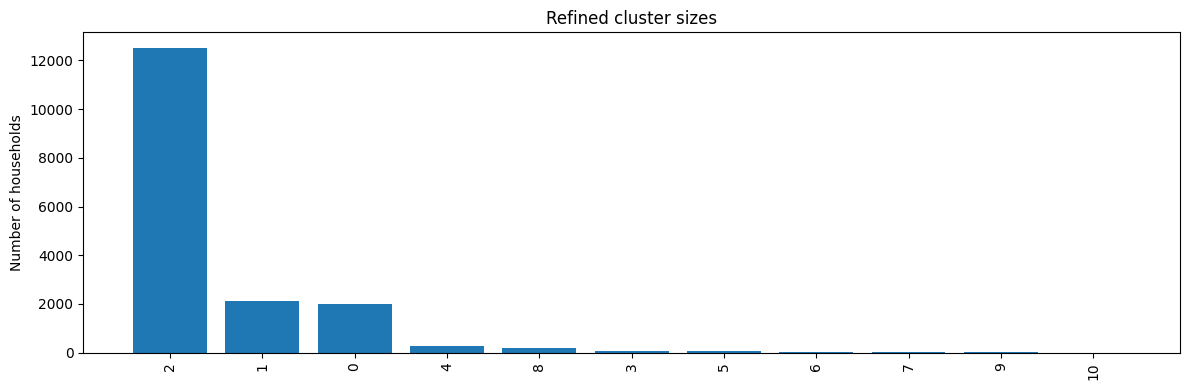

Cluster counts:
0: 2001 households
1: 2120 households
2: 12527 households
3: 87 households
4: 279 households
5: 84 households
6: 47 households
7: 46 households
8: 175 households
9: 25 households
10: 2 households


In [33]:
cluster_sizes = feature_df_clean["RefinedCluster"].value_counts(dropna=False).reset_index()
cluster_sizes.columns = ["Cluster", "Count"]
cluster_sizes["Pct"] = 100 * cluster_sizes["Count"] / cluster_sizes["Count"].sum()

display(cluster_sizes.sort_values("Count", ascending=False))

plt.figure(figsize=(12, 4))
plt.bar(cluster_sizes["Cluster"].astype(str), cluster_sizes["Count"])
plt.xticks(rotation=90)
plt.title("Refined cluster sizes")
plt.ylabel("Number of households")
plt.tight_layout()
plt.show()

print("Cluster counts:")
for cluster, count in feature_df_clean["RefinedCluster"].value_counts().sort_index().items():
    print(f"{cluster}: {count} households")


## 13. Summarize refined clusters

In [34]:
summary_cols = [
    c for c in [
        "mean",
        "std",
        "cv",
        "zero_fraction",
        "avg_zero_run_length",
        "acf7",
        "trend_slope",
        "weekday_weekend_gap",
        "burstiness",
        "num_peaks",
    ]
    if c in feature_df_clean.columns
]

cluster_summary = feature_df_clean.groupby("RefinedCluster")[summary_cols].mean()
display(cluster_summary.sort_index())


,mean,std,cv,zero_fraction,avg_zero_run_length,acf7,trend_slope,weekday_weekend_gap,burstiness,num_peaks
RefinedCluster,,,,,,,,,,
0,2.900000,2.535878,0.530124,0.000804,0.061109,0.722312,-0.030199,-0.016358,-0.188733,4.694511
1,2.055357,1.874779,0.617612,0.000653,0.050050,0.498845,0.009314,0.021324,-0.098760,4.667966
2,1.974846,1.178629,0.310742,0.000330,0.027969,0.280019,-0.000336,-0.076684,-0.472178,4.755380
3,0.398922,0.572995,1.194157,0.440315,2.600764,0.170902,0.000382,0.504670,0.569259,4.048305
4,0.892921,1.140474,0.996755,0.407386,2.978755,0.464807,0.002088,-0.144732,0.296643,4.095999
5,2.568231,2.602117,0.736215,0.341696,3.337364,0.825127,-0.034291,0.021548,0.035755,4.194123
6,1.321713,1.525451,0.872095,0.123679,1.889290,0.481033,0.008073,-0.184735,0.155583,4.525855
7,2.554366,2.372339,0.603219,0.115249,1.845280,0.779818,-0.027603,-0.011493,-0.099139,4.630133
8,1.207421,0.889162,0.482999,0.112462,2.094983,0.368395,-0.001835,-0.016255,-0.244351,4.672367


## 14. PCA visualization

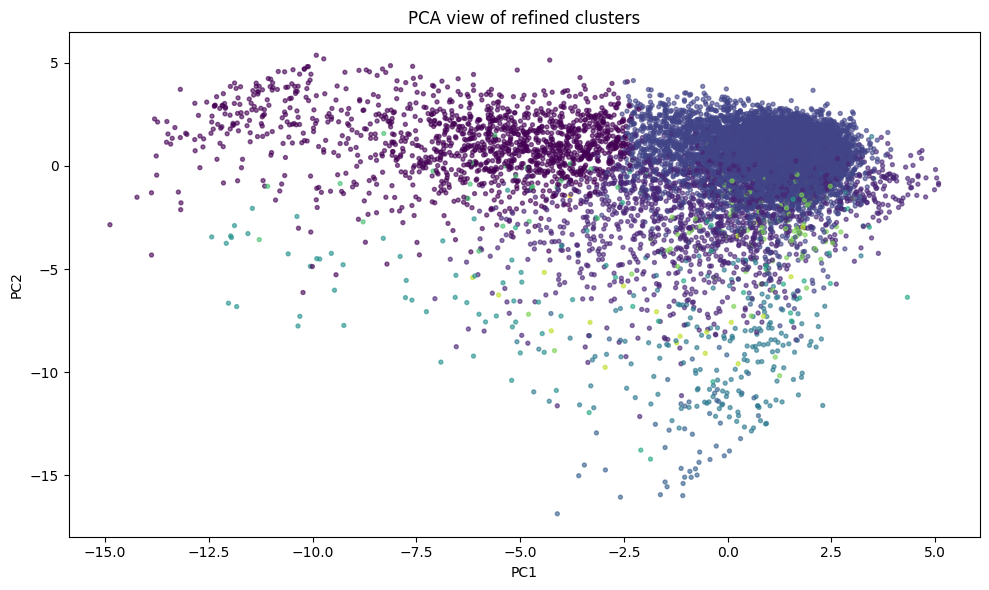

In [35]:
X_all, feat_cols = get_feature_matrix(feature_df_clean)
scaler_all = RobustScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_all_scaled)

plot_df = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "Cluster": feature_df_clean["RefinedCluster"].values,
})

sample_plot_df = plot_df.sample(min(12000, len(plot_df)), random_state=RANDOM_STATE)

cluster_to_int = {
    c: i for i, c in enumerate(sorted(sample_plot_df["Cluster"].dropna().unique()))
}
colors = sample_plot_df["Cluster"].map(cluster_to_int)

plt.figure(figsize=(10, 6))
plt.scatter(sample_plot_df["PC1"], sample_plot_df["PC2"], c=colors, s=8, alpha=0.6)
plt.title("PCA view of refined clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


## 15. Save outputs

In [36]:
from pathlib import Path

candidates = [Path("outputs/feature"), Path("notebooks/outputs/feature")]

save_dir = None
for p in candidates:
    if p.exists():
        save_dir = p
        break

if save_dir is None:
    save_dir = candidates[0]
    save_dir.mkdir(parents=True, exist_ok=True)

clusters_csv = feature_df_clean[["ID", "RefinedClusterLocal"]].rename(
    columns={"RefinedClusterLocal": "cluster"}
)
clusters_named_csv = feature_df_clean[["ID", "RefinedCluster"]].rename(
    columns={"RefinedCluster": "cluster"}
)

clusters_csv.to_csv(save_dir / "clusters.csv", index=False)
clusters_named_csv.to_csv(save_dir / "clusters_named.csv", index=False)

print("Saved:")
print(save_dir / "clusters.csv")
print(save_dir / "clusters_named.csv")
# 4 random ids from the 2, 3, 4 and 8 cluster print them from row time series and color them based on the final clusters

Saved:
outputs/feature/clusters.csv
outputs/feature/clusters_named.csv


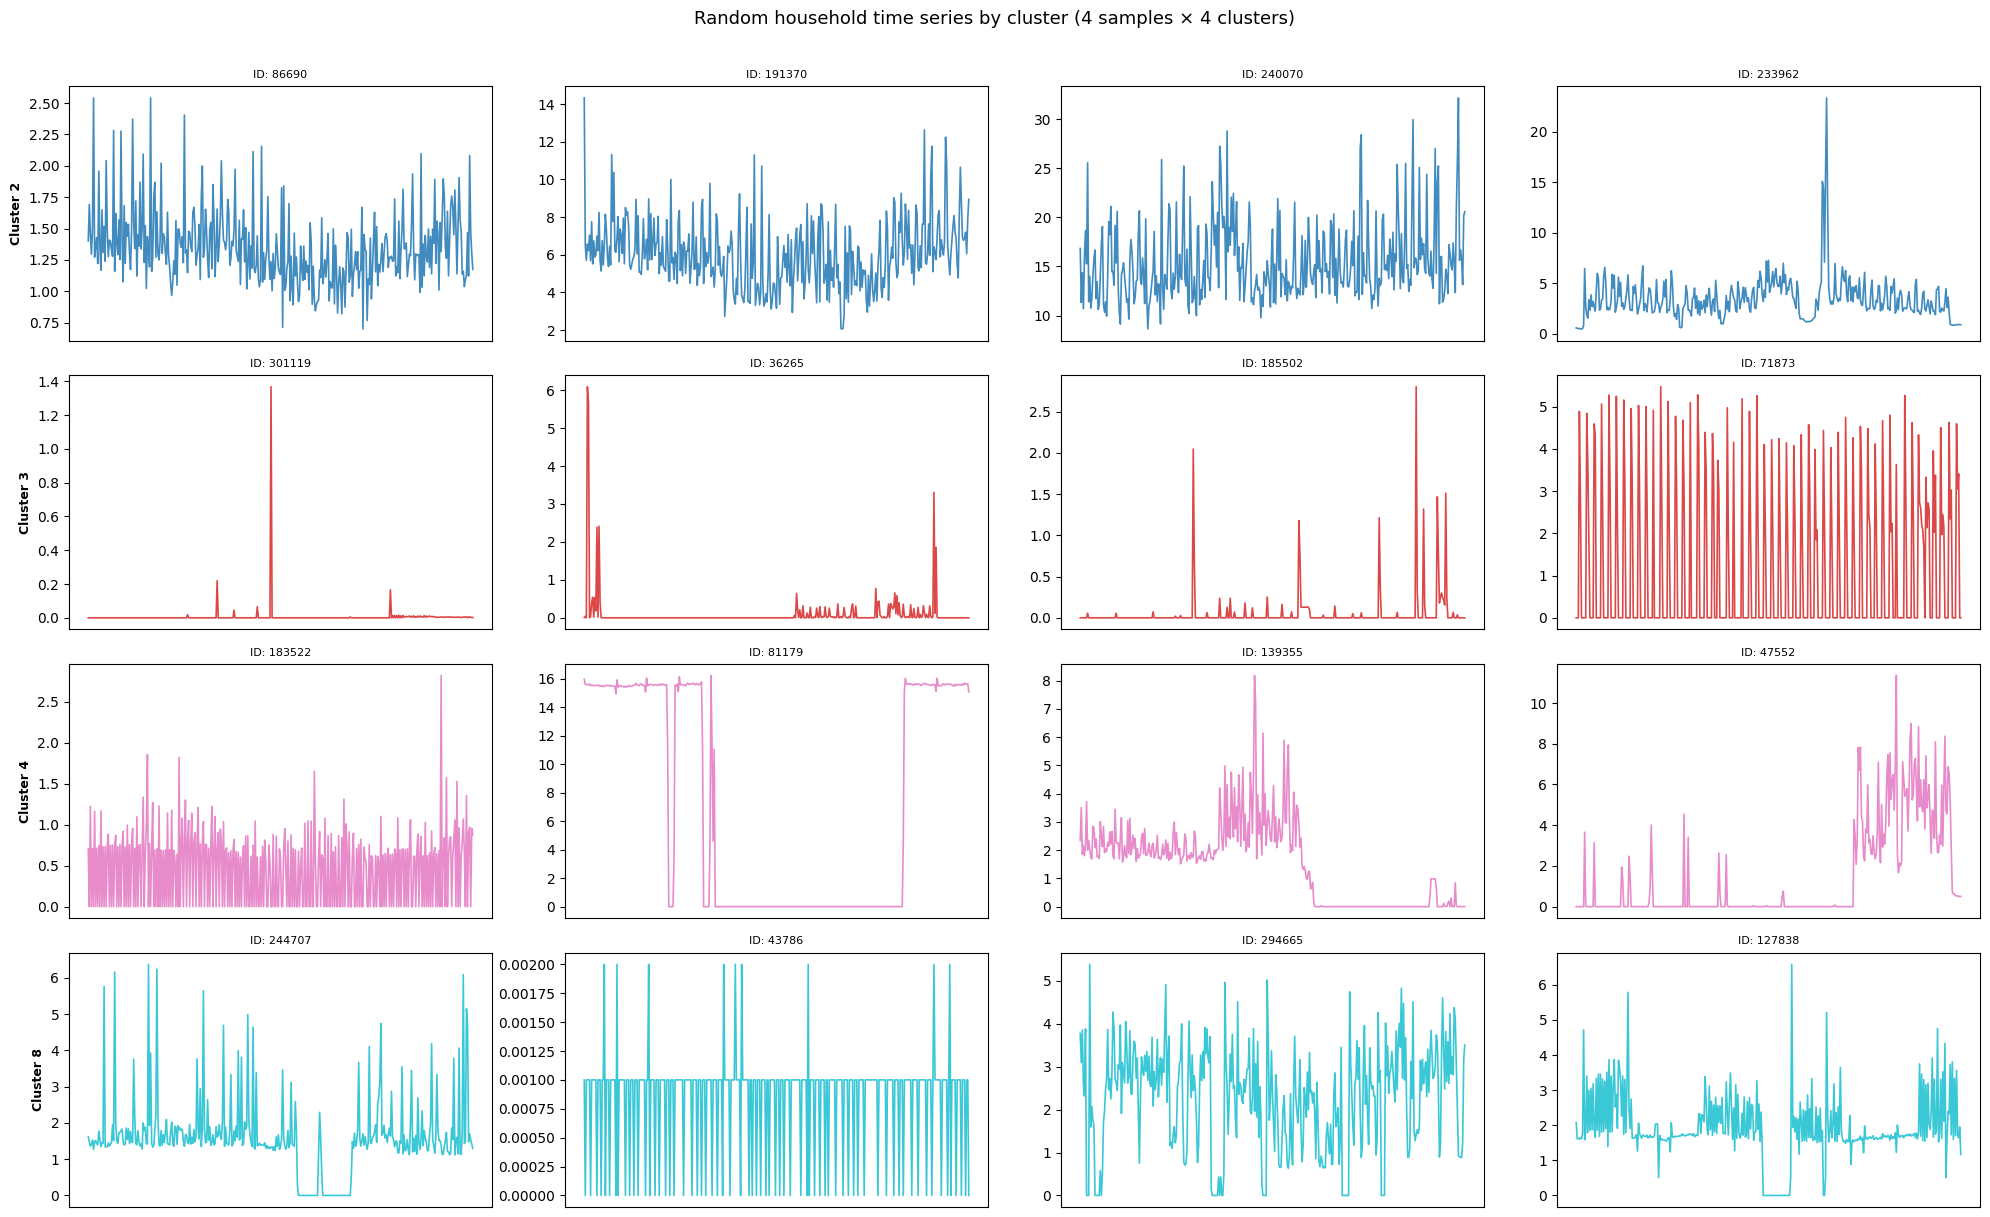

In [37]:
import matplotlib.cm as cm

# Clusters to sample from
target_clusters = [2, 3, 4, 8]
n_per_cluster = 4

fig, axes = plt.subplots(
    len(target_clusters), n_per_cluster, figsize=(20, 12), sharey=False
)

# Build a color map: one color per target cluster
cmap = cm.get_cmap("tab10", len(target_clusters))
cluster_colors = {c: cmap(i) for i, c in enumerate(target_clusters)}

for row_idx, cluster_id in enumerate(target_clusters):
    # Get IDs belonging to this cluster
    cluster_ids = feature_df_clean.loc[
        feature_df_clean["RefinedCluster"] == cluster_id, "ID"
    ]

    if len(cluster_ids) == 0:
        print(f"Cluster {cluster_id} has no members — skipping.")
        for col_idx in range(n_per_cluster):
            axes[row_idx, col_idx].set_visible(False)
        continue

    # Sample up to n_per_cluster IDs
    sampled_ids = cluster_ids.sample(min(n_per_cluster, len(cluster_ids)))

    for col_idx, hh_id in enumerate(sampled_ids):
        ax = axes[row_idx, col_idx]
        ts = series_matrix.loc[hh_id]

        ax.plot(
            range(len(ts)),  # use integer index to avoid date-label clutter
            ts.values,
            color=cluster_colors[cluster_id],
            linewidth=1.2,
            alpha=0.85,
        )
        ax.set_title(f"ID: {hh_id}", fontsize=8)
        ax.set_xlabel("")
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

        # Only label the leftmost column
        if col_idx == 0:
            ax.set_ylabel(f"Cluster {cluster_id}", fontsize=9, fontweight="bold")

fig.suptitle(
    "Random household time series by cluster (4 samples × 4 clusters)",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()
plt.show()

## Notes

- `RefinedClusterLocal` is only local within each sparsity bucket.
- `RefinedCluster` is the globally interpretable label to use in reporting.
- The PCA plot is for visualization only.
- If `pycatch22` is not installed, the notebook still runs without it.
